# Mall customer segmentation

Daily notebook — small experiment, fully reproducible (seed pinned below).

The classic mall-customers clustering exercise on synthetic data: income vs spending score.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1270

rng = np.random.RandomState(SEED)
n = 600
age = np.clip(rng.normal(38, 13, size=n), 18, 70).round(0).astype(int)
income = np.clip(rng.normal(60, 22, size=n), 15, 140).round(1)
spend = np.clip(0.55 * income + rng.normal(0, 12, size=n) - 0.25 * (age - 38), 1, 99).round(1)
df = pd.DataFrame({"Age": age, "AnnualIncome_k": income, "SpendingScore": spend})
print("shape:", df.shape)
print(df.head(3).to_string())
print(df.describe().round(1).to_string())


shape: (600, 3)
   Age  AnnualIncome_k  SpendingScore
0   51            43.4           17.8
1   50            78.1           42.2
2   18            19.1            1.0
         Age  AnnualIncome_k  SpendingScore
count  600.0           600.0          600.0
mean    38.5            59.0           33.1
std     12.4            22.1           16.6
min     18.0            15.0            1.0
25%     29.0            43.2           21.1
50%     38.0            59.1           33.2
75%     47.0            75.2           44.8
max     70.0           119.4           85.7


## Cluster

silhouette: 0.345
          Age  AnnualIncome_k  SpendingScore
cluster                                     
0        34.6            51.5           43.0
1        38.7            30.9           14.0
2        40.5            77.9           38.2
3        35.1            88.3           57.9
4        41.8            55.7           22.8

cluster sizes:
 cluster
0    112
1    133
2    130
3     88
4    137


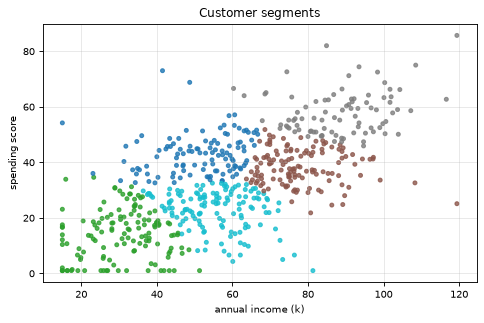

In [ ]:

X = StandardScaler().fit_transform(df[["AnnualIncome_k", "SpendingScore"]])
km = KMeans(n_clusters=5, n_init=10, random_state=SEED).fit(X)
df["cluster"] = km.labels_
print(f"silhouette: {silhouette_score(X, km.labels_):.3f}")
print(df.groupby("cluster")[["Age", "AnnualIncome_k", "SpendingScore"]].mean().round(1).to_string())
print("\ncluster sizes:\n", df["cluster"].value_counts().sort_index().to_string())
fig, ax = plt.subplots()
sc = ax.scatter(df["AnnualIncome_k"], df["SpendingScore"], c=df["cluster"], cmap="tab10", s=12, alpha=0.8)
ax.set_xlabel("annual income (k)"); ax.set_ylabel("spending score")
ax.set_title("Customer segments")


## What I learned

- Five segments with the usual story: high income/low spend (savers), low income/high spend, etc.
- k=5 was a guess — the elbow check is tomorrow's notebook.